# Legal corpora — EUR-Lex & UN parallel

A look at the two raw sources under `data/legal/`, side by side. Nothing here writes
anything; it only reads.

Both fit the benchmark's premise — the *same* document exists in several languages as a
human translation — but they differ in the unit that is parallel:

| | EUR-Lex (MultiEURLEX) | UN Parallel v1.0 (6-way) |
|---|---|---|
| on disk | 3 parquet files, 2.1 GB | 6 plain-text files + `.ids`, 15 GB |
| a row is | one law, with 23 language fields | one *sentence group*, line-aligned across 6 files |
| family key | `celex_id` | first token of `.ids` (UN document symbol) |
| documents | 35,395 | 86,307 |
| languages | 23 (coverage varies by accession year) | 6, complete |

The UN files are multi-GB, so every cell below streams or slices — nothing reads a whole
language file into memory.

> Needs a kernel: `uv pip install ipykernel` (or pick the `.venv` interpreter in VS Code).

In [28]:
from __future__ import annotations

import itertools
import json
from collections import Counter
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

ROOT = Path.cwd()
if not (ROOT / "data").exists():          # notebook opened from notebooks/
    ROOT = ROOT.parent
EURLEX = ROOT / "data/legal/eurlex"
UN = ROOT / "data/legal/un_parallel/6way"

EU_LANGS = ["bg", "cs", "da", "de", "el", "en", "es", "et", "fi", "fr", "hr", "hu",
            "it", "lt", "lv", "mt", "nl", "pl", "pt", "ro", "sk", "sl", "sv"]
UN_LANGS = ["ar", "en", "es", "fr", "ru", "zh"]

pd.set_option("display.max_colwidth", 100)
pd.set_option("display.width", 200)


def preview(s: str | None, n: int = 120) -> str:
    """Collapse whitespace and truncate — parquet text fields carry hard newlines."""
    s = " ".join((s or "").split())
    return s[:n] + ("…" if len(s) > n else "")


INK, MUTED, HUE = "#1f2328", "#6b7280", "#3b6fb6"


def style(ax, title="", xlabel="", ylabel=""):
    """Recessive frame: the marks carry the chart, the furniture stays quiet."""
    ax.set_title(title, color=INK, fontsize=12, loc="left", pad=10)
    ax.set_xlabel(xlabel, color=MUTED, fontsize=9)
    ax.set_ylabel(ylabel, color=MUTED, fontsize=9)
    ax.tick_params(colors=MUTED, labelsize=9, length=0)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color("#d7dae0")
    ax.set_axisbelow(True)
    return ax


assert EURLEX.exists() and UN.exists(), "run from the repo root or notebooks/"
print("eurlex :", EURLEX)
print("un     :", UN)

eurlex : /home/mehdi/Projects/CLIR_benchmark/data/legal/eurlex
un     : /home/mehdi/Projects/CLIR_benchmark/data/legal/un_parallel/6way


---
## 1. EUR-Lex — one row per law, 23 language fields

### 1.1 What the fetch step recorded

In [29]:
man = json.loads((EURLEX / "manifest.json").read_text())
print(man["source_dataset"])
print(man["selection"])
print(f'{man["documents_kept"]:,} kept of {man["total_documents_scanned"]:,} scanned '
      f'· years {man["year_range"][0]}–{man["year_range"][1]}')
print("by type :", man["by_type"])
print("by split:", man["by_split"])

coverage = (pd.Series(man["language_nonempty_counts"], name="docs")
              .sort_values(ascending=False)
              .to_frame())
coverage["share"] = (coverage["docs"] / man["documents_kept"]).map("{:.0%}".format)
coverage.T

coastalcph/multi_eurlex (revision refs/convert/parquet)
sector 3 secondary legislation with CELEX type R (regulation) or L (directive)
35,395 kept of 51,000 scanned · years 1958–2016
by type : {'regulation': 32693, 'directive': 2702}
by split: {'test': 3470, 'train': 28600, 'validation': 3325}


,da,el,de,en,nl,it,fr,es,pt,fi,...,lt,cs,sl,et,sk,hu,mt,bg,ro,hr
docs,35395,35395,35395,35395,35395,35395,35395,34552,34304,29484,...,19092,19087,19073,19058,18994,18842,15334,14892,14849,8903
share,100%,100%,100%,100%,100%,100%,100%,98%,97%,83%,...,54%,54%,54%,54%,54%,53%,43%,42%,42%,25%


Coverage tracks EU accession: `hr` only from 2013, `bg`/`ro` from 2007, the 2004 group from
2004. So a "23-language corpus" is really 7 languages deep, 23 wide — which decides how
many language pairs a query can actually be evaluated on.

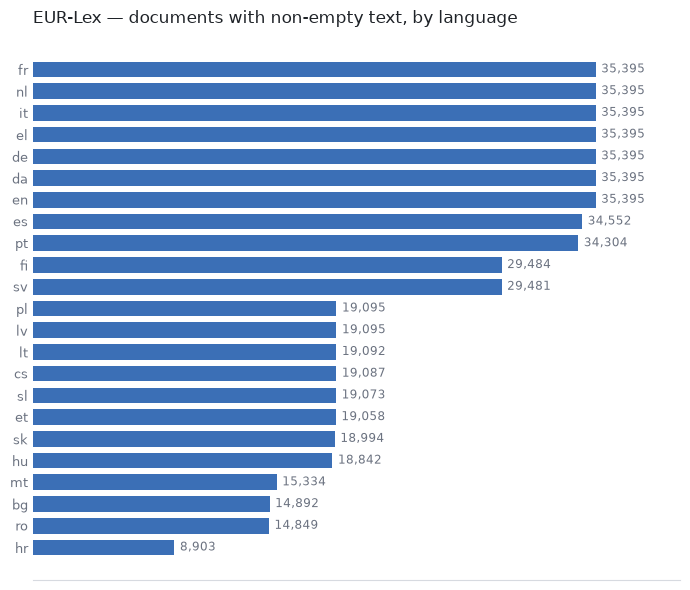

In [30]:
fig, ax = plt.subplots(figsize=(7, 6))
c = coverage["docs"].sort_values()
ax.barh(c.index, c.values, color=HUE, height=0.72)
for lang, v in c.items():
    ax.text(v + 350, lang, f"{v:,}", va="center", color=MUTED, fontsize=8.5)
ax.set_xlim(0, c.max() * 1.15)
ax.xaxis.set_visible(False)
style(ax, "EUR-Lex — documents with non-empty text, by language")
plt.tight_layout()
plt.show()

### 1.2 The files

In [31]:
splits = {s: pq.ParquetFile(EURLEX / f"documents/{s}.parquet")
          for s in ("train", "validation", "test")}
for name, pf in splits.items():
    mb = (EURLEX / f"documents/{name}.parquet").stat().st_size / 1e6
    print(f"{name:<11} {pf.metadata.num_rows:>6,} rows  {pf.num_row_groups:>3} row groups  {mb:>7.0f} MB")

print()
print(splits["train"].schema_arrow)

train       28,600 rows   82 row groups     1404 MB
validation   3,325 rows   10 row groups      263 MB
test         3,470 rows   10 row groups      498 MB

celex_id: string
doc_type: string
year: int32
text: struct<bg: string, cs: string, da: string, de: string, el: string, en: string, es: string, et: strin (... 182 chars omitted)
  child 0, bg: string
  child 1, cs: string
  child 2, da: string
  child 3, de: string
  child 4, el: string
  child 5, en: string
  child 6, es: string
  child 7, et: string
  child 8, fi: string
  child 9, fr: string
  child 10, hr: string
  child 11, hu: string
  child 12, it: string
  child 13, lt: string
  child 14, lv: string
  child 15, mt: string
  child 16, nl: string
  child 17, pl: string
  child 18, pt: string
  child 19, ro: string
  child 20, sk: string
  child 21, sl: string
  child 22, sv: string
labels: list<element: int64>
  child 0, element: int64


`text` is a **struct of 23 string fields**, one per language — that is what keeps the row
parallel. Missing languages are empty strings, not nulls.

Because parquet is columnar, the metadata columns can be read in full without touching the
2 GB of text:

In [32]:
meta = pd.concat(
    [pq.read_table(EURLEX / f"documents/{s}.parquet",
                   columns=["celex_id", "doc_type", "year"]).to_pandas().assign(split=s)
     for s in splits],
    ignore_index=True,
)
print(f"{len(meta):,} documents · {meta.celex_id.nunique():,} distinct CELEX ids")
pd.crosstab(meta.year // 10 * 10, meta.doc_type).rename_axis("decade")

35,395 documents · 35,395 distinct CELEX ids


doc_type,directive,regulation
decade,,
1950,0,1
1960,11,5
1970,209,505
1980,517,4294
1990,706,7959
2000,817,13492
2010,442,6437


### 1.3 One law, 23 ways

In [33]:
# A recent law, so every language (including hr, 2013+) is present.
sample_rg = splits["train"].read_row_groups([splits["train"].num_row_groups - 1]).to_pandas()
full = sample_rg[sample_rg.text.map(lambda d: all((d.get(l) or "").strip() for l in EU_LANGS))]
law = full.sort_values("year").iloc[-1]

print(f'{law.celex_id}  {law.doc_type}  {law.year}  · EuroVoc labels {[int(x) for x in law.labels]}')
pd.DataFrame(
    [(lg, len(law.text[lg]), preview(law.text[lg], 95)) for lg in EU_LANGS],
    columns=["lang", "chars", "opening"],
).set_index("lang")

32009L0149  directive  2009  · EuroVoc labels [7, 8, 4, 1]


,chars,opening
lang,,
bg,4416,ДИРЕКТИВА 2009/149/ЕО НА КОМИСИЯТА от 27 ноември 2009 година за изменение на Директива 2004/49/…
cs,3589,"SMĚRNICE KOMISE 2009/149/ES ze dne 27. listopadu 2009, kterou se mění směrnice Evropského parla…"
da,4224,KOMMISSIONENS DIREKTIV 2009/149/EF af 27. november 2009 om ændring af Europa-Parlamentets og Rå…
de,4656,RICHTLINIE 2009/149/EG DER KOMMISSION vom 27. November 2009 zur Änderung der Richtlinie 2004/49…
el,4450,ΟΔΗΓΊΑ 2009/149/ΕΚ ΤΗΣ ΕΠΙΤΡΟΠΉΣ της 27ης Νοεμβρίου 2009 για την τροποποίηση της οδηγίας 2004/4…
en,4058,COMMISSION DIRECTIVE 2009/149/EC of 27 November 2009 amending Directive 2004/49/EC of the Europ…
es,4657,DIRECTIVA 2009/149/CE DE LA COMISIÓN de 27 de noviembre de 2009 por la que se modifica la Direc…
et,3857,"KOMISJONI DIREKTIIV 2009/149/EÜ, 27. november 2009, millega muudetakse Euroopa Parlamendi ja nõ…"
fi,4503,"KOMISSION DIREKTIIVI 2009/149/EY, annettu 27 päivänä marraskuuta 2009, Euroopan parlamentin ja …"


In [34]:
# The whole English text of that law, as stored (hard newlines preserved).
print(law.text["en"][:1500])

COMMISSION DIRECTIVE 2009/149/EC
of 27 November 2009
amending Directive 2004/49/EC of the European Parliament and of the Council as regards Common Safety Indicators and common methods to calculate accident costs
(Text with EEA relevance)
THE COMMISSION OF THE EUROPEAN COMMUNITIES,
Having regard to the Treaty establishing the European Community,
Having regard to Directive 2004/49/EC of the European Parliament and of the Council of 29 April 2004 on safety of the Community’s railways and amending Council Directive 95/18/EC on the licensing of railway undertakings and Directive 2001/14/EC on the allocation of railway infrastructure capacity and the levying of charges for the use of railway infrastructure and safety certification (Railway Safety Directive) (1), and in particular Article 5(2) thereof,
Having regard to the recommendation of the European Railway Agency (ERA/REC/SAF/02-2008) of 29 September 2008,
Whereas:
(1)
Article 5(2) of Directive 2004/49/EC, as corrected, provides for the 

### 1.4 Browsing the English texts

Three helpers: `browse` lists laws with their opening line, `show` prints one in full, `read`
renders one in a scrollable pane. All of them go through `get_law`, which locates a CELEX id
and decodes **only the row group it lives in** (~350 laws of the 28,600), so a lookup costs
~0.3 s instead of loading the 1.4 GB file.

The `opening` column in `browse` is clipped by pandas at `display.max_colwidth` (100, set in
the setup cell) — raise it with `pd.set_option("display.max_colwidth", 250)` for a longer
first line, or use `show`/`read` below to see a whole document.

In [35]:
_celex = {s: pq.read_table(EURLEX / f"documents/{s}.parquet",
                           columns=["celex_id"]).to_pandas().celex_id
          for s in splits}
_rg_start = {s: np.cumsum([0] + [pf.metadata.row_group(i).num_rows
                                 for i in range(pf.num_row_groups)])
             for s, pf in splits.items()}


def get_law(celex_id: str) -> pd.Series:
    """One law as a row — all 23 language fields. Decodes a single row group."""
    for s, pf in splits.items():
        hit = np.flatnonzero((_celex[s] == celex_id).to_numpy())
        if hit.size:
            rg = int(np.searchsorted(_rg_start[s], hit[0], side="right") - 1)
            return pf.read_row_groups([rg]).to_pandas().iloc[int(hit[0]) - int(_rg_start[s][rg])]
    raise KeyError(f"{celex_id} not in the corpus")


def browse(n: int = 8, *, years=None, doc_type=None, lang="en", seed=0, chars=110):
    """Sample n laws and show how each one opens. Filter by year range and/or type."""
    sel = meta
    if years is not None:
        sel = sel[sel.year.between(*years)]
    if doc_type is not None:
        sel = sel[sel.doc_type == doc_type]
    rows = [get_law(c) for c in sel.sample(min(n, len(sel)), random_state=seed).celex_id]
    return pd.DataFrame(
        [(r.celex_id, r.doc_type, r.year, len(r.text[lang]), preview(r.text[lang], chars))
         for r in rows],
        columns=["celex_id", "type", "year", "chars", f"opening ({lang})"],
    ).set_index("celex_id")


browse(8, years=(2010, 2016))          # try doc_type="directive", seed=1, lang="fr"

,type,year,chars,opening (en)
celex_id,,,,
32015R0497,regulation,2015,1846,COMMISSION REGULATION (EU) 2015/497 of 20 March 2015 establishing a prohibition of fishing for s...
32010R0851,regulation,2010,1835,COMMISSION REGULATION (EU) No 851/2010 of 27 September 2010 amending for the 136th time Council ...
32014R0725,regulation,2014,2139,COMMISSION IMPLEMENTING REGULATION (EU) No 725/2014 of 30 June 2014 amending Council Regulation ...
32014R0004,regulation,2014,3281,COMMISSION REGULATION (EU) No 4/2014 of 6 January 2014 amending Regulation (EC) No 640/2009 impl...
32011R0573,regulation,2011,1098,COUNCIL IMPLEMENTING REGULATION (EU) No 573/2011 of 16 June 2011 implementing Article 16(2) of R...
32012R0217,regulation,2012,1326,COMMISSION IMPLEMENTING REGULATION (EU) No 217/2012 of 13 March 2012 entering a name in the regi...
32013R0663,regulation,2013,2039,COMMISSION REGULATION (EU) No 663/2013 of 10 July 2013 establishing a prohibition of fishing for...
32010R0979,regulation,2010,1326,COMMISSION REGULATION (EU) No 979/2010 of 29 October 2010 entering a name in the register of pro...


In [36]:
row = browse(8, years=(2010, 2016)).iloc[1]

In [37]:
show(row.name)                              # full text — row.name is the celex_id
get_law(row.name).text["en"] 

NameError: name 'show' is not defined

In [39]:
def show(celex_id: str, lang: str = "en", chars: int | None = None) -> None:
    """Print a law's text as stored — the whole thing unless `chars` truncates it."""
    row = get_law(celex_id)
    text = row.text[lang]
    if not text:
        print(f"{celex_id}: no {lang} text")
        return
    print(f"{row.celex_id} · {row.doc_type} · {row.year} · {lang} · {len(text):,} chars "
          f"· EuroVoc {[int(x) for x in row.labels]}")
    print("─" * 90)
    print(text if chars is None
          else text[:chars] + (f"\n… [{len(text) - chars:,} more chars]" if len(text) > chars else ""))


show("32010R0979")                     # full text; show(..., chars=2000) to cut it short


32010R0979 · regulation · 2010 · en · 1,326 chars · EuroVoc [17, 7, 3, 6, 18]
──────────────────────────────────────────────────────────────────────────────────────────
COMMISSION REGULATION (EU) No 979/2010
of 29 October 2010
entering a name in the register of protected designations of origin and protected geographical indications (Porc de Franche-Comté (PGI))
THE EUROPEAN COMMISSION,
Having regard to the Treaty on the Functioning of the European Union,
Having regard to Council Regulation (EC) No 510/2006 of 20 March 2006 on the protection of geographical indications and designations of origin for agricultural products and foodstuffs (1), and in particular the first subparagraph of Article 7(4) thereof,
Whereas:
(1)
Pursuant to the first subparagraph of Article 6(2) of Regulation (EC) No 510/2006, France’s application to register the name ‘Porc de Franche-Comté’ was published in the Official Journal of the European Union (2).
(2)
As no statement of objection under Article 7 of Regulat

`print` is fine for a short regulation, but the long ones run to 200,000 characters and the
text has no soft wrapping. `read` renders a law in a scrollable pane instead, and puts
several languages in columns so the same passage can be compared across them.

In [ ]:
import html as _html

from IPython.display import HTML, display


def read(celex_id: str, langs=("en",), height: int = 560) -> None:
    """Render a law full-length in a scrollable pane, one column per language."""
    row = get_law(celex_id)
    present = [lg for lg in langs if row.text[lg]]
    if not present:
        print(f"{celex_id}: no text in {', '.join(langs)}")
        return
    cols = "".join(
        '<div style="flex:1;min-width:0;padding:0 14px;border-left:1px solid #8884">'
        f'<div style="font:600 12px/1.8 system-ui;opacity:.6">{lg} · {len(row.text[lg]):,} chars</div>'
        '<div style="white-space:pre-wrap;font:13px/1.55 system-ui">'
        f'{_html.escape(row.text[lg])}</div></div>'
        for lg in present
    )
    display(HTML(
        f'<div style="font:600 13px/1.8 system-ui">{row.celex_id} · {row.doc_type} · {row.year} '
        f'· EuroVoc {[int(x) for x in row.labels]}</div>'
        f'<div style="display:flex;max-height:{height}px;overflow:auto;border:1px solid #8884;'
        f'border-radius:6px;padding:10px 0">{cols}</div>'
    ))


read("32014R0596", langs=("en", "fr", "de"))    # market abuse regulation — 197k chars in en


### 1.5 How parallel is a typical law?

Random row groups rather than the head of the file — splits are chronological, so the first
rows are all old law and would misrepresent language coverage.

In [8]:
rng = np.random.default_rng(0)
pf = splits["train"]
rg_ids = sorted(rng.choice(pf.num_row_groups, size=8, replace=False).tolist())
sample = pf.read_row_groups(rg_ids).to_pandas()

chars = pd.DataFrame({lg: sample.text.map(lambda d, lg=lg: len(d.get(lg) or ""))
                      for lg in EU_LANGS})
n_langs = (chars > 0).sum(axis=1)

print(f"sample: {len(sample):,} laws, years {sample.year.min()}–{sample.year.max()}")
print(f"languages per law — median {n_langs.median():.0f}, mean {n_langs.mean():.1f}")
n_langs.value_counts().sort_index().rename("laws").rename_axis("languages_present").to_frame().T

sample: 2,784 laws, years 1972–2010
languages per law — median 11, mean 14.9


languages_present,7,8,9,10,11,12,13,16,18,19,20,21,22,23
laws,82,33,481,4,998,1,2,3,9,299,90,67,404,311


In [9]:
lengths = chars.replace(0, np.nan)
tbl = pd.DataFrame({
    "present": (chars > 0).sum(),
    "median_chars": lengths.median().round(0),
    "p90_chars": lengths.quantile(0.9).round(0),
    # Paired against the same law's English text, so the languages that only cover
    # recent (longer) law are not credited with being verbose.
    "vs_en": lengths.div(lengths["en"], axis=0).median().round(2),
})
tbl.sort_values("vs_en", ascending=False).T

,es,nl,el,it,pt,fr,mt,ro,de,pl,...,da,en,sv,lt,sk,hr,cs,et,lv,sl
present,2685.00,2784.00,2784.0,2784.0,2661.00,2784.00,826.00,786.00,2784.00,1182.00,...,2784.0,2784.0,2173.0,1182.00,1172.00,361.00,1178.00,1181.0,1183.0,1182.00
median_chars,3041.00,2902.00,2888.0,2900.0,2896.00,2838.00,4036.00,3757.00,2786.00,2896.00,...,2639.0,2624.0,2614.0,2625.00,2564.00,4539.00,2470.00,2508.0,2499.0,2428.00
p90_chars,12871.00,12353.00,12580.0,12242.0,12414.00,12345.00,26390.00,23634.00,11886.00,19256.00,...,11238.0,11463.0,11873.0,18052.00,17440.00,34100.00,16949.00,17059.0,17580.0,16675.00
vs_en,1.15,1.11,1.1,1.1,1.09,1.08,1.08,1.07,1.06,1.04,...,1.0,1.0,1.0,0.94,0.93,0.93,0.91,0.9,0.9,0.87


`vs_en` is the translation-expansion signal, measured per law rather than across laws — the
naive comparison of medians would rank `hr` and `mt` longest, when all that says is that
those languages only cover the recent, longer acts.

Worth remembering when a retrieval model truncates at a fixed token budget: the same law
fits in English and gets cut in Greek or Finnish. And characters are not tokens — for `el`,
`bg` and `ru` the token count inflates further.

In [ ]:
labels = pq.read_table(EURLEX / "documents/train.parquet", columns=["labels"]).to_pandas().labels
per_doc = labels.map(len)
print(f"EuroVoc labels per law — median {per_doc.median():.0f}, max {per_doc.max()}")
top = Counter(int(x) for row in labels for x in row).most_common(10)
pd.DataFrame(top, columns=["eurovoc_id", "laws"]).set_index("eurovoc_id").T

### 1.6 What is inside one document

A real EU act is a hierarchy — title, recitals, chapters, sections, articles, paragraphs,
points, annexes. **None of it survives as structure here.** `text[lang]` is one flat string;
the only trace of the hierarchy is that structural lines sit alone on their own
`\n`-separated line:

```
HAVE ADOPTED THIS DIRECTIVE:
CHAPTER 1                                      ← chapter number
GENERAL PROVISIONS                             ← its rubric
Article 1                                      ← article number, alone
Subject matter and scope                       ← the article's rubric
The purpose of this Directive is to ensure …   ← the text of paragraph 1
This Directive shall apply to electrical …     ← the text of paragraph 2
```

So the levels are recoverable *by regex on line starts*, not readable from a schema. Three
things are lost outright:

- **Paragraph numbers are unreliable.** Article 1 above should read "1. The purpose…",
  "2. This Directive…" — the numbers are gone. Elsewhere in the same act they survive as a
  literal `1. ` prefix. Roughly 3 in 4 laws have some numbered paragraphs; none has them
  everywhere.
- **Enumerators are detached.** Recital and point markers `(1)`, `(a)` are on their own
  line, one line above the text they number.
- **Annexes are absent.** Every act ends at the signature block, so `Annex I` is referenced
  by the articles but its content is not in the corpus.


In [ ]:
import re

# The hierarchy as it actually appears: a line that is *only* a marker.
STRUCT = {
    "chapter":       r"^(TITLE|CHAPTER|SECTION)\b",
    "article":       r"^Article\s+\d+$",
    "enumerator":    r"^\(\d+\)$",          # recital (1), or point (1) inside an article
    "point (a)":     r"^\([a-z]\)$",
    "numbered para": r"^\d+\.\s+\S",        # "1. Manufacturers shall …"
    "annex heading": r"^ANNEX\b",
}


def outline(celex_id: str, lang: str = "en", width: int = 80) -> pd.DataFrame:
    """The skeleton of a law — every structural line, in order, with its line number."""
    text = get_law(celex_id).text[lang]
    return pd.DataFrame(
        [(i, kind, s[:width])
         for i, line in enumerate(text.split("\n"))
         for s in [line.strip()]
         for kind, pat in STRUCT.items() if re.match(pat, s)],
        columns=["line", "kind", "text"],
    ).set_index("line")


ol = outline("32014L0035")              # low-voltage directive, 29 articles
print(ol.kind.value_counts().to_string())
ol.loc[88:105]                          # the seam: recitals end, chapter and articles begin


In [ ]:
# How common is each level? Reuses `sample` from 1.5, restricted to laws long enough
# to have any internal structure at all.
def markers(text: str) -> dict:
    lines = [x.strip() for x in text.split("\n")]
    return {"lines": len(lines)} | {k: sum(bool(re.match(p, x)) for x in lines)
                                    for k, p in STRUCT.items()}


longish = sample[sample.text.map(lambda d: len(d["en"]) > 3000)]
mk = pd.DataFrame([markers(d["en"]) for d in longish.text])

print(f"{len(longish):,} laws with more than 3,000 characters of English")
pd.DataFrame({"mean per law": mk.mean().round(1),
              "laws with ≥ 1": (mk > 0).mean().map("{:.0%}".format)})


In [ ]:
# Does the structure line up across languages? Only if you parse it per language:
# line counts differ, and every language names an article differently.
ARTICLE = {"en": r"^Article\s+(\d+)$",   "fr": r"^Article\s+(\d+)$",
           "de": r"^Artikel\s+(\d+)$",   "it": r"^Articolo\s+(\d+)$",
           "es": r"^Artículo\s+(\d+)$"}

law_x = get_law("32014L0035")
pd.DataFrame({
    lg: {"lines": len(law_x.text[lg].split("\n")),
         "articles matched": sum(bool(re.match(p, l.strip())) for l in law_x.text[lg].split("\n")),
         "first heading": next(l.strip() for l in law_x.text[lg].split("\n")
                               if re.match(r"^(Article|Artikel|Articolo|Artículo)\b", l.strip()))}
    for lg, p in ARTICLE.items()
})


Two consequences for the pipeline, if articles are ever wanted as retrieval units rather
than whole laws:

- **Line position is not parallel.** The same directive is 312 lines in `en` and `de`, 298
  in `fr`, `it` and `es` — so the *n*-th line is not the *n*-th line of the translation.
  Article numbers are, which makes the article number the only usable alignment key.
- **The key needs per-language rules.** French writes `Article premier`, not `Article 1`, so
  the naive regex silently drops the first article of every French act. Each language has
  its own quirk of this kind; any article-level split has to be verified per language, not
  assumed from English.

Article-level segmentation is workable — 97% of the longer acts have `Article N` headings —
but it is a parsing job with a per-language verification step, not something the data hands
over ready-made.

---
## 2. UN Parallel v1.0 — 6-way line alignment

No document objects on disk: six text files where **line N is the same sentence group in
every language**, plus a `.ids` file that says which document line N came from. Document
structure has to be rebuilt from `.ids`.

In [ ]:
files = sorted(UN.glob("UNv1.0.6way.*"))
pd.DataFrame([(f.name, round(f.stat().st_size / 1e9, 2)) for f in files],
             columns=["file", "GB"]).set_index("file").T

In [ ]:
# Peek at the raw alignment: same line number, six files.
def head_lines(path: Path, n: int) -> list[str]:
    with open(path, encoding="utf-8") as f:
        return [l.rstrip("\n") for l in itertools.islice(f, n)]

for name in ["ids"] + UN_LANGS:
    print(f"{name:>4} | {head_lines(UN / f'UNv1.0.6way.{name}', 1)[0][:100]}")

An `.ids` line is `<document symbol> <lang>:<sentence>:<?> …` — the first token is the UN
document symbol (`1994/s/res/918_1994_` = Security Council resolution 918 (1994)), and the
rest records which source sentences were merged into this group per language. Only the
first token matters for grouping.

Scanning all 11.4 M `.ids` lines takes ~3 s and gives every document's line range:

In [ ]:
starts, ids_seen, prev = [], [], None
with open(UN / "UNv1.0.6way.ids", encoding="utf-8") as f:
    for i, line in enumerate(f):
        doc = line.split(" ", 1)[0]
        if doc != prev:
            starts.append(i)
            ids_seen.append(doc)
            prev = doc
n_lines = i + 1

docs = pd.DataFrame({"doc_id": ids_seen, "start": starts})
docs["n_lines"] = np.diff(docs.start.tolist() + [n_lines])
docs = docs.set_index("doc_id")

print(f"{n_lines:,} aligned lines · {len(docs):,} documents")
print(f"contiguous: {docs.index.is_unique}  (each document's lines are one unbroken block)")
docs.head()

In [ ]:
parts = docs.index.to_series().str.split("/")
docs["year"] = pd.to_numeric(parts.str[0], errors="coerce")
docs["body"] = parts.str[1]

print("document bodies:")
print(docs.body.value_counts().head(10).to_string())
print()
print("years:")
print(docs.year.value_counts().sort_index().to_string())

`a` = General Assembly, `s` = Security Council, `e` = ECOSOC, `td` = UNCTAD, `fccc` = climate
convention, and so on. The corpus is concentrated in 1990–2014.

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
bins = np.logspace(0, np.log10(docs.n_lines.max()), 45)
ax.hist(docs.n_lines, bins=bins, color=HUE)
ax.set_xscale("log")
ax.grid(axis="y", color="#eceef1", lw=0.8)
style(ax, "UN 6-way — sentence groups per document", "lines per document (log)", "documents")
plt.tight_layout()
plt.show()

docs.n_lines.describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]).round(1).to_frame("lines_per_doc").T

### 2.1 The aligned window

Loading a prefix of all six files is cheap (~0.3 s / 100 k lines) and is the fastest way to
just *look* at the data.

In [ ]:
WINDOW = 60_000
window = pd.DataFrame({lg: head_lines(UN / f"UNv1.0.6way.{lg}", WINDOW) for lg in UN_LANGS})
window.insert(0, "doc_id", [l.split(" ", 1)[0]
                            for l in head_lines(UN / "UNv1.0.6way.ids", WINDOW)])

print(f"{len(window):,} lines · {window.doc_id.nunique():,} documents in the window")
window.head(6).assign(**{lg: window[lg].head(6).map(lambda s: preview(s, 55)) for lg in UN_LANGS})

In [ ]:
w = window[UN_LANGS].map(len)
lens = pd.DataFrame({"median_chars": w.median(), "mean_chars": w.mean().round(1)})
lens["vs_en"] = (lens.median_chars / lens.loc["en", "median_chars"]).round(2)
lens.T

`zh` is short in characters and `ar`/`ru` long — a reminder that character length is not
token length, and that a per-language character cutoff would silently truncate unevenly.

### 2.2 Reconstructing a whole document

With the line index, any document can be pulled from the six files by slicing. The files
are not seekable by line, so this streams forward — a document at line 5 M costs about a
second per language, run in parallel here.

In [ ]:
def read_doc(doc_id: str, langs=UN_LANGS) -> dict[str, list[str]]:
    """Return the sentence groups of one document, per language."""
    start, n = int(docs.loc[doc_id, "start"]), int(docs.loc[doc_id, "n_lines"])

    def slice_lang(lg):
        with open(UN / f"UNv1.0.6way.{lg}", encoding="utf-8") as f:
            return [l.rstrip("\n") for l in itertools.islice(f, start, start + n)]

    with ThreadPoolExecutor(len(langs)) as pool:
        return dict(zip(langs, pool.map(slice_lang, langs)))


target = docs[(docs.n_lines.between(15, 40))].index[0]
doc = read_doc(target)

print(f"{target}  ·  {len(doc['en'])} sentence groups")
pd.DataFrame({lg: [len(" ".join(doc[lg])), preview(" ".join(doc[lg]), 90)] for lg in UN_LANGS},
             index=["chars", "opening"]).T

In [ ]:
# Same document, sentence by sentence, two languages side by side.
pd.DataFrame({"en": doc["en"], "fr": doc["fr"]}).head(10).map(lambda s: preview(s, 85))

---
## 3. Side by side

What each source gives the pipeline, in the same units.

In [ ]:
# Document length for the UN side is measured on the loaded window only — the whole
# corpus would mean reading 15 GB.
un_doc_chars = (window.groupby("doc_id")["en"]
                      .apply(lambda s: sum(map(len, s)))
                      .median())

pd.DataFrame({
    "EUR-Lex": {
        "documents": f"{man['documents_kept']:,}",
        "languages": len(EU_LANGS),
        "family key": "celex_id",
        "parallel unit": "document",
        "fully parallel docs": f"{(n_langs == len(EU_LANGS)).mean():.0%} of sample (all 23 langs)",
        "median doc chars (en)": f"{lengths['en'].median():,.0f}",
        "on disk": "2.1 GB parquet",
        "years": f"{man['year_range'][0]}–{man['year_range'][1]}",
    },
    "UN 6-way": {
        "documents": f"{len(docs):,}",
        "languages": len(UN_LANGS),
        "family key": ".ids first token",
        "parallel unit": "sentence group",
        "fully parallel docs": "100% (all 6 langs, by construction)",
        "median doc chars (en)": f"{un_doc_chars:,.0f} (window)",
        "on disk": "15 GB text",
        "years": f"{int(docs.year.min())}–{int(docs.year.max())}",
    },
})

Two different shapes of the same idea. EUR-Lex is wide and shallow — 23 languages, but only
7 of them cover the whole corpus, and each law is short. The UN corpus is narrow and
complete — 6 languages with no gaps, longer documents, but the parallelism is at sentence
level and document text only exists once `.ids` is grouped.